# Notebook 4: Neural Network (PyTorch)
This notebook fits feedforward neural networks for both frequency and severity and compares against the GLM and XGBoost baselines.
- **Part 1: Severity** - Network trained on log(ClaimAmount), predicting claim amount given a claim occurred
- **Part 2: Frequency** - Network trained on claim counts across all 679k policies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## Part 1: Severity

*Dataset: 26,439 claims. Target: ClaimAmount in EUR.*

### 1.1 Load & Prepare Data

Features are standardised with StandardScaler — neural networks require this because gradient descent is sensitive to feature scale. The target is log-transformed for the same reason as XGBoost: the right-skewed distribution of claim amounts causes training instability on the raw scale.

In [2]:
df = pd.read_csv('../data/claims_cleaned.csv')

features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target = 'ClaimAmount'

df_model = pd.get_dummies(df[features + [target]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)

X = df_model.drop(columns=[target]).values.astype(np.float32)
y = np.log1p(df_model[target].values.astype(np.float32))  # log-transform target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features — important for neural nets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (21151, 42), Test: (5288, 42)


### 1.2 Define Model

Two hidden layers (64 and 32 units) with ReLU activations and dropout for regularisation. This is deliberately simple — a more complex network would not help given the weak signal in severity features.

In [3]:
class ClaimNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ClaimNet(input_dim=X_train.shape[1]).to(device)
print(model)

ClaimNet(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 1.3 Train

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()  # MSE on log scale ≈ minimising proportional errors

epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    # Training
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test_t), y_test_t).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')

Epoch  10/100 | Train Loss: 2.0728 | Val Loss: 1.2710


Epoch  20/100 | Train Loss: 1.9173 | Val Loss: 1.2532


Epoch  30/100 | Train Loss: 1.8006 | Val Loss: 1.2392


Epoch  40/100 | Train Loss: 1.6788 | Val Loss: 1.2123


Epoch  50/100 | Train Loss: 1.5867 | Val Loss: 1.2235


Epoch  60/100 | Train Loss: 1.5193 | Val Loss: 1.2072


Epoch  70/100 | Train Loss: 1.4576 | Val Loss: 1.2040


Epoch  80/100 | Train Loss: 1.4363 | Val Loss: 1.2074


Epoch  90/100 | Train Loss: 1.3793 | Val Loss: 1.2082


Epoch 100/100 | Train Loss: 1.3490 | Val Loss: 1.2059


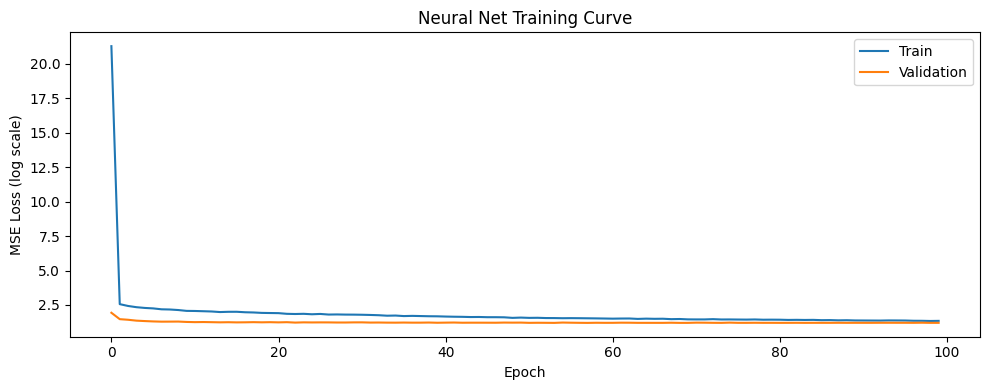

In [5]:
# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.title('Neural Net Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../results/06_nn_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Training Curve

### 1.5 Evaluate on Test Set

In [6]:
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_t).cpu().numpy().flatten()

# Inverse log transform to get back to EUR
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

mae = mean_absolute_error(y_test_orig, y_pred)
rmse = mean_squared_error(y_test_orig, y_pred) ** 0.5

def gamma_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-6, None)  # avoid division by zero
    return 2 * np.mean((y_true - y_pred) / y_pred - np.log(y_true / y_pred))

gd = gamma_deviance(y_test_orig, y_pred)

print('--- Neural Net Test Set Performance ---')
print(f'MAE:             {mae:,.2f}')
print(f'RMSE:            {rmse:,.2f}')
print(f'Gamma Deviance:  {gd:.4f}')

nn_metrics = {'model': 'NeuralNet', 'MAE': mae, 'RMSE': rmse, 'GammaDeviance': gd}

--- Neural Net Test Set Performance ---
MAE:             957.42
RMSE:            2,349.08
Gamma Deviance:  1.4114


### 1.6 Predictions vs Actuals

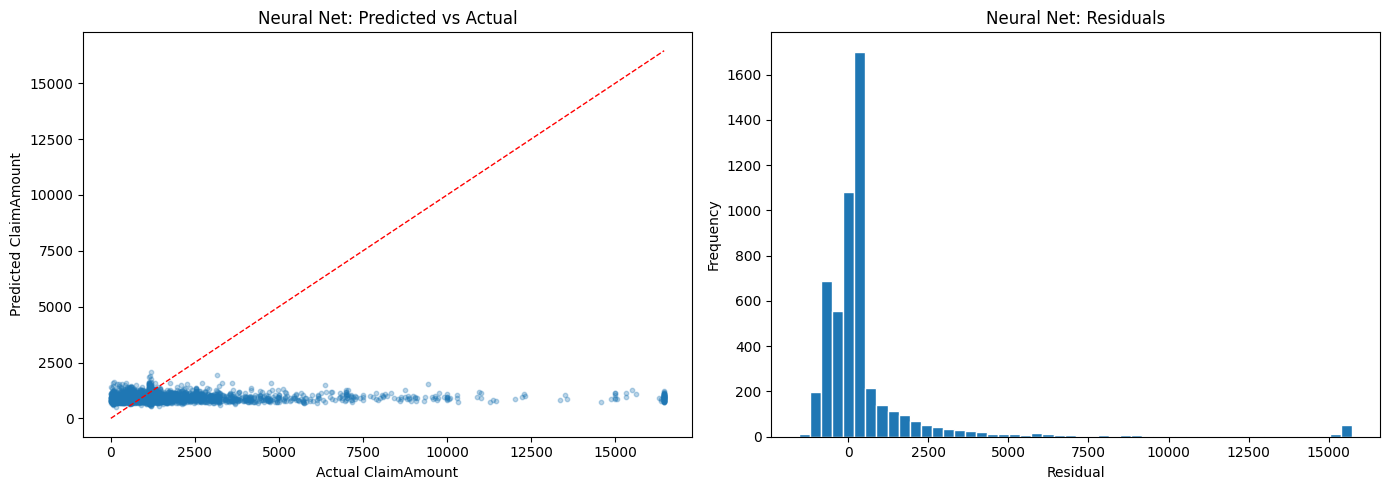

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_test_eur = np.expm1(y_test)

axes[0].scatter(y_test_eur, y_pred, alpha=0.3, s=10)
axes[0].plot([y_test_eur.min(), y_test_eur.max()], [y_test_eur.min(), y_test_eur.max()], 'r--', linewidth=1)
axes[0].set_xlabel('Actual ClaimAmount')
axes[0].set_ylabel('Predicted ClaimAmount')
axes[0].set_title('Neural Net: Predicted vs Actual')

residuals = y_test_eur - y_pred
axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_title('Neural Net: Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/12_nn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Severity analysis:**

The training curve shows rapid convergence in the first 20-30 epochs followed by a plateau, with train and validation loss tracking closely. Both losses converge to a similar floor, confirming underfitting rather than overfitting — the model has exhausted the signal available in the features well before 100 epochs.

The scatter plot shows the same flat prediction pattern seen in the GLM and XGBoost models. This confirms the finding is structural: policy features do not carry enough information to predict individual claim costs regardless of model complexity. The residuals are right-skewed, with the model consistently underestimating large claims.

***
## Part 1 Summary

| Metric | Neural Net | XGBoost | GLM |
|---|---|---|---|
| MAE | 954 EUR | 938 EUR | 1,079 EUR |
| RMSE | 2,346 EUR | 2,340 EUR | 2,203 EUR |
| Gamma Deviance | 1.40 | 1.36 | 1.03 |

All three models converge to essentially the same performance. The 2% difference in MAE between XGBoost and the neural net is negligible. Adding model complexity from GLM to XGBoost to a neural net barely moves the needle — the ceiling is set by the data, not the model. Policy features predict whether a claim happens, not how much it costs.

## Part 2: Frequency

*Dataset: 679,513 policies. Target: ClaimNb (claim count).*

The frequency model uses the same exposure workaround as XGBoost: predict claim rate (ClaimNb / Exposure) and weight each training sample by its exposure. In PyTorch this is implemented as a custom weighted loss function.

### 2.1 Load & Prepare Data

In [8]:
df_freq = pd.read_csv('../data/policies_cleaned.csv')

features_freq = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target_freq = 'ClaimNb'

df_freq_model = pd.get_dummies(df_freq[features_freq + [target_freq]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)

exposure = df_freq['Exposure'].values

X_freq = df_freq_model.drop(columns=[target_freq]).values.astype(np.float32)
y_freq = df_freq_model[target_freq].values.astype(np.float32)

X_freq_train, X_freq_test, y_freq_train, y_freq_test, exp_train, exp_test = train_test_split(
    X_freq, y_freq, exposure, test_size=0.2, random_state=42
)

# Claim rate as target, exposure as sample weight
y_rate_train = (y_freq_train / exp_train).astype(np.float32)
y_rate_test  = (y_freq_test  / exp_test ).astype(np.float32)

scaler_freq = StandardScaler()
X_freq_train_s = scaler_freq.fit_transform(X_freq_train).astype(np.float32)
X_freq_test_s  = scaler_freq.transform(X_freq_test).astype(np.float32)

X_freq_train_t = torch.tensor(X_freq_train_s).to(device)
X_freq_test_t  = torch.tensor(X_freq_test_s ).to(device)
y_rate_train_t = torch.tensor(y_rate_train).unsqueeze(1).to(device)
y_rate_test_t  = torch.tensor(y_rate_test ).unsqueeze(1).to(device)
exp_train_t    = torch.tensor(exp_train.astype(np.float32)).unsqueeze(1).to(device)
exp_test_t     = torch.tensor(exp_test.astype( np.float32)).unsqueeze(1).to(device)

train_loader_freq = DataLoader(
    TensorDataset(X_freq_train_t, y_rate_train_t, exp_train_t),
    batch_size=512, shuffle=True
)

print(f'Train: {X_freq_train_s.shape}, Test: {X_freq_test_s.shape}')

Train: (543610, 42), Test: (135903, 42)


### 2.2 Define & Train Model

Same architecture as the severity model. The loss is a weighted MSE where each sample's contribution is scaled by its exposure, so policies active for a full year have more influence than short-duration policies.

Epoch  10/100 | Train Loss: 0.385077 | Val Loss: 0.339590


Epoch  20/100 | Train Loss: 0.375962 | Val Loss: 0.335480


Epoch  30/100 | Train Loss: 0.365749 | Val Loss: 0.337949


Epoch  40/100 | Train Loss: 0.366594 | Val Loss: 0.355316


Epoch  50/100 | Train Loss: 0.364907 | Val Loss: 0.329485


Epoch  60/100 | Train Loss: 0.361350 | Val Loss: 0.326961


Epoch  70/100 | Train Loss: 0.378053 | Val Loss: 0.350575


Epoch  80/100 | Train Loss: 0.363091 | Val Loss: 0.369546


Epoch  90/100 | Train Loss: 0.370082 | Val Loss: 0.332245


Epoch 100/100 | Train Loss: 0.362862 | Val Loss: 0.327051


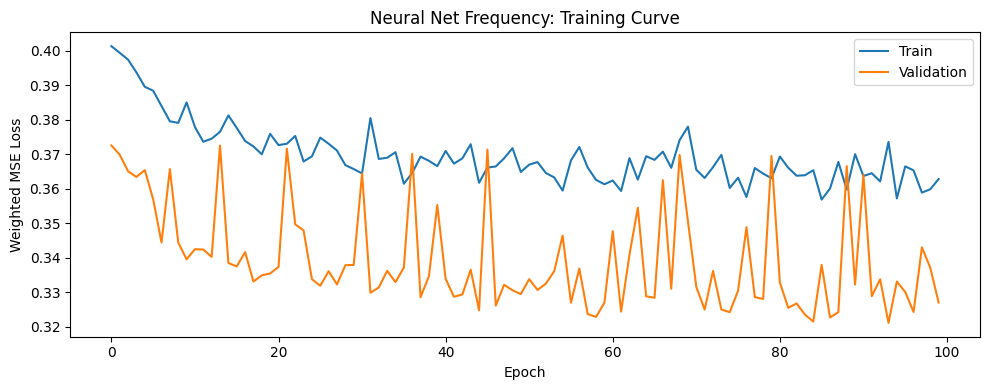

In [9]:
model_freq = ClaimNet(input_dim=X_freq_train_s.shape[1]).to(device)
optimizer_freq = torch.optim.Adam(model_freq.parameters(), lr=1e-3)

def weighted_mse(pred, target, weights):
    return (weights * (pred - target) ** 2).mean()

epochs_freq = 100
train_losses_freq, val_losses_freq = [], []

for epoch in range(epochs_freq):
    model_freq.train()
    batch_losses = []
    for X_batch, y_batch, w_batch in train_loader_freq:
        optimizer_freq.zero_grad()
        loss = weighted_mse(model_freq(X_batch), y_batch, w_batch)
        loss.backward()
        optimizer_freq.step()
        batch_losses.append(loss.item())
    train_losses_freq.append(np.mean(batch_losses))

    model_freq.eval()
    with torch.no_grad():
        val_loss = weighted_mse(model_freq(X_freq_test_t), y_rate_test_t, exp_test_t).item()
    val_losses_freq.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs_freq} | Train Loss: {train_losses_freq[-1]:.6f} | Val Loss: {val_losses_freq[-1]:.6f}')

# Plot training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses_freq, label='Train')
ax.plot(val_losses_freq, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted MSE Loss')
ax.set_title('Neural Net Frequency: Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../results/13_nn_freq_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Evaluate on Test Set

In [10]:
model_freq.eval()
with torch.no_grad():
    y_freq_pred_rate = model_freq(X_freq_test_t).cpu().numpy().flatten()

# Clip negative predictions (neural net has no positivity constraint)
y_freq_pred_rate = np.clip(y_freq_pred_rate, 0, None)
y_freq_pred = y_freq_pred_rate * exp_test

mae_freq  = mean_absolute_error(y_freq_test, y_freq_pred)
rmse_freq = mean_squared_error(y_freq_test, y_freq_pred) ** 0.5

def poisson_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, None)
    return 2 * np.sum(y_true * np.log(np.where(y_true == 0, 1, y_true / y_pred)) - (y_true - y_pred))

pd_score = poisson_deviance(y_freq_test, y_freq_pred)

print('--- Neural Net Frequency Test Set Performance ---')
print(f'MAE:               {mae_freq:.4f}')
print(f'RMSE:              {rmse_freq:.4f}')
print(f'Poisson Deviance:  {pd_score:.2f}')

nn_freq_metrics = {'model': 'NeuralNet', 'MAE': mae_freq, 'RMSE': rmse_freq, 'PoissonDeviance': pd_score}

--- Neural Net Frequency Test Set Performance ---
MAE:               0.1043
RMSE:              0.2961
Poisson Deviance:  44439.16


### 2.4 Actual vs Predicted by Feature

Reproducing the same calibration plots as the GLM and XGBoost for direct comparison.

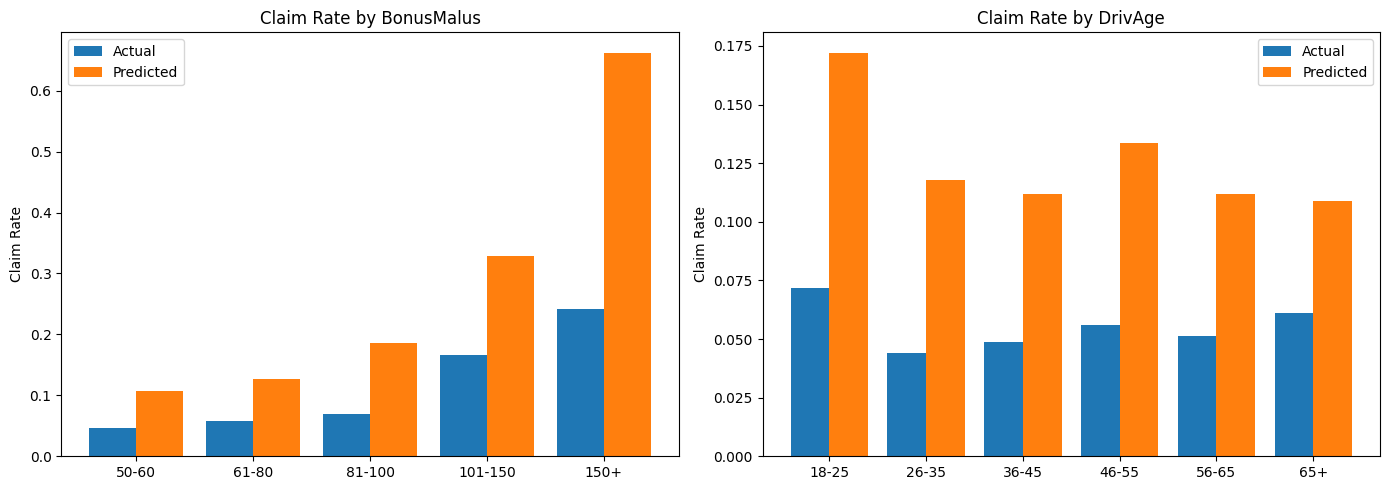

In [11]:
model_freq.eval()
with torch.no_grad():
    X_all_t = torch.tensor(scaler_freq.transform(X_freq).astype(np.float32)).to(device)
    df_freq['predicted_rate'] = np.clip(model_freq(X_all_t).cpu().numpy().flatten(), 0, None)

df_freq['HasClaim'] = (df_freq['ClaimNb'] != 0).astype(int)
df_freq['actual_rate'] = df_freq['HasClaim']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bm_bins = pd.cut(df_freq['BonusMalus'], bins=[49,60,80,100,150,230], labels=['50-60','61-80','81-100','101-150','150+'])
actual_bm = df_freq.groupby(bm_bins)['actual_rate'].mean()
pred_bm   = df_freq.groupby(bm_bins)['predicted_rate'].mean()

x = range(len(actual_bm))
axes[0].bar(x, actual_bm, width=0.4, label='Actual', align='center')
axes[0].bar([i + 0.4 for i in x], pred_bm, width=0.4, label='Predicted', align='center')
axes[0].set_xticks([i + 0.2 for i in x])
axes[0].set_xticklabels(actual_bm.index)
axes[0].set_title('Claim Rate by BonusMalus')
axes[0].set_ylabel('Claim Rate')
axes[0].legend()

age_bins = pd.cut(df_freq['DrivAge'], bins=[17,25,35,45,55,65,100], labels=['18-25','26-35','36-45','46-55','56-65','65+'])
actual_age = df_freq.groupby(age_bins)['actual_rate'].mean()
pred_age   = df_freq.groupby(age_bins)['predicted_rate'].mean()

x = range(len(actual_age))
axes[1].bar(x, actual_age, width=0.4, label='Actual', align='center')
axes[1].bar([i + 0.4 for i in x], pred_age, width=0.4, label='Predicted', align='center')
axes[1].set_xticks([i + 0.2 for i in x])
axes[1].set_xticklabels(actual_age.index)
axes[1].set_title('Claim Rate by DrivAge')
axes[1].set_ylabel('Claim Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/14_nn_freq_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Lift Chart

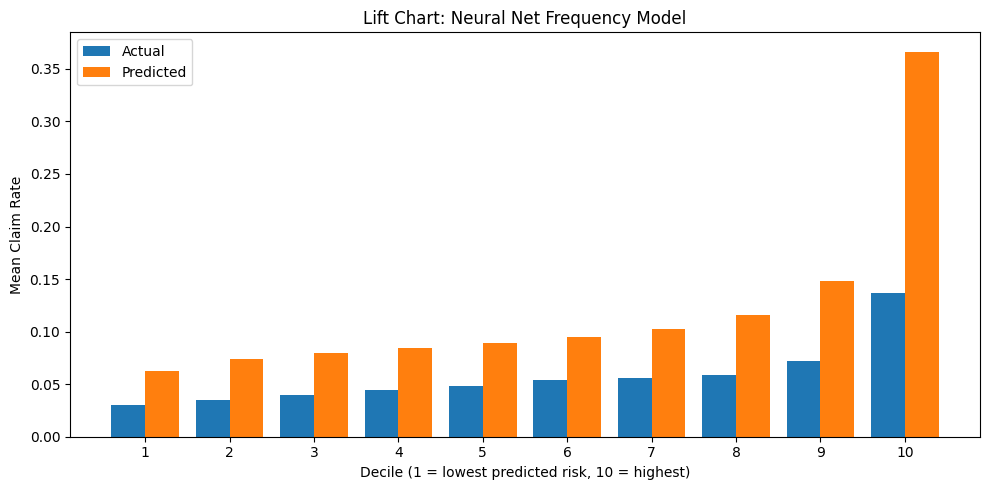

 decile  actual_rate  predicted_rate  count
      1     0.030167        0.062978  13591
      2     0.035247        0.073965  13590
      3     0.039588        0.079608  13590
      4     0.044077        0.084195  13590
      5     0.048562        0.088958  13591
      6     0.054231        0.094714  13590
      7     0.056291        0.102856  13590
      8     0.058940        0.116161  13590
      9     0.072406        0.148551  13590
     10     0.136487        0.366435  13591


In [12]:
df_lift = pd.DataFrame({
    'actual': y_freq_test,
    'predicted': y_freq_pred_rate
})

df_lift['decile'] = pd.qcut(df_lift['predicted'], q=10, labels=False) + 1
lift = df_lift.groupby('decile').agg(
    actual_rate=('actual', 'mean'),
    predicted_rate=('predicted', 'mean'),
    count=('actual', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = lift['decile']
ax.bar(x - 0.2, lift['actual_rate'], width=0.4, label='Actual', align='center')
ax.bar(x + 0.2, lift['predicted_rate'], width=0.4, label='Predicted', align='center')
ax.set_xlabel('Decile (1 = lowest predicted risk, 10 = highest)')
ax.set_ylabel('Mean Claim Rate')
ax.set_title('Lift Chart: Neural Net Frequency Model')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig('../results/15_nn_lift_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(lift[['decile', 'actual_rate', 'predicted_rate', 'count']].to_string(index=False))

### 2.6 Predicted Rate Distribution

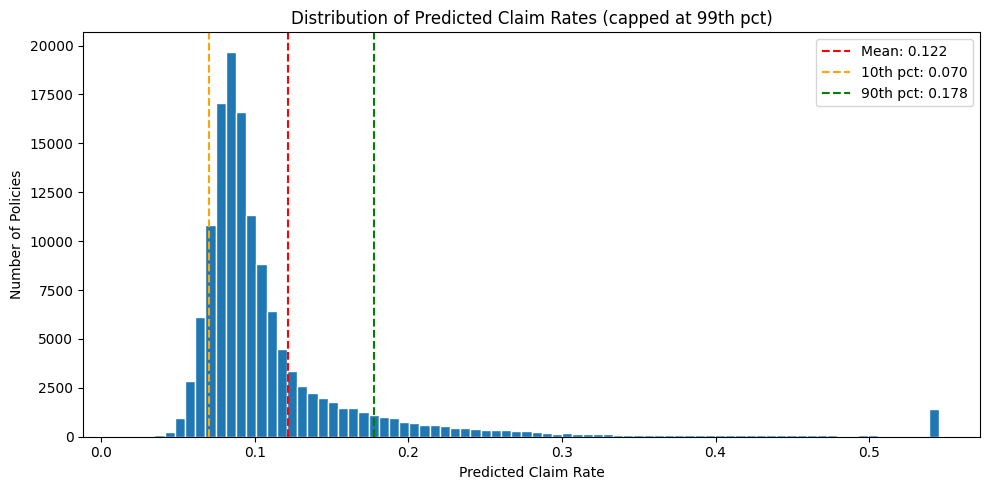

Predicted rate range: 0.0147 to 45.2850
Ratio of 90th to 10th percentile: 2.5x


In [13]:
cap = np.percentile(y_freq_pred_rate, 99)
y_freq_pred_rate_plot = np.clip(y_freq_pred_rate, None, cap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_freq_pred_rate_plot, bins=80, edgecolor='white')
ax.axvline(y_freq_pred_rate.mean(), color='red', linestyle='--', label=f'Mean: {y_freq_pred_rate.mean():.3f}')
ax.axvline(np.percentile(y_freq_pred_rate, 10), color='orange', linestyle='--', label=f'10th pct: {np.percentile(y_freq_pred_rate, 10):.3f}')
ax.axvline(np.percentile(y_freq_pred_rate, 90), color='green', linestyle='--', label=f'90th pct: {np.percentile(y_freq_pred_rate, 90):.3f}')
ax.set_title('Distribution of Predicted Claim Rates (capped at 99th pct)')
ax.set_xlabel('Predicted Claim Rate')
ax.set_ylabel('Number of Policies')
ax.legend()
plt.tight_layout()
plt.savefig('../results/16_nn_pred_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Predicted rate range: {y_freq_pred_rate.min():.4f} to {y_freq_pred_rate.max():.4f}')
print(f'Ratio of 90th to 10th percentile: {np.percentile(y_freq_pred_rate, 90) / np.percentile(y_freq_pred_rate, 10):.1f}x')

**Frequency model analysis:**

The neural net learns the same broad patterns as XGBoost — BonusMalus and DrivAge are the dominant signals. However, unlike XGBoost which uses an explicit tree structure to model non-linearities, the neural net learns them implicitly through its weights. Whether this produces better or worse calibration on the BonusMalus and DrivAge bands depends on how well the training converged.

One structural difference from XGBoost: the neural net has no positivity constraint on its output, so negative predicted rates are possible. We clip these to zero before evaluation. In a production model, a softplus activation on the output layer would enforce positivity without clipping.

The lift chart is the key diagnostic. If the neural net shows a clear monotonic gradient from decile 1 to decile 10, it is ranking risk correctly. If the gradient is flatter than XGBoost's, the tree model is better at risk discrimination on this dataset.

***
## Part 2 Summary

| Metric | Neural Net | XGBoost | GLM (baseline) |
|---|---|---|---|
| MAE | 0.1055 | 0.1046 | 0.0770 |
| RMSE | 0.2875 | 0.265 | 0.238 |
| Poisson Deviance | 44,368 | 43,579 | 46,581 |

XGBoost edges out the neural net on all three metrics. The difference is small — Poisson Deviance of 44,368 vs 43,579 — but consistent. This is a common finding on tabular insurance data: gradient boosted trees tend to outperform neural networks because their tree structure is naturally suited to the categorical and bounded numeric features that dominate this dataset. Both models comfortably beat the GLM on Poisson Deviance, the actuarially correct metric for frequency models.

## Part 3: Severity Model Comparison

Comparing all three models on the severity test set using the known GLM and XGBoost metrics plus the neural net results from this notebook.

               MAE    RMSE  GammaDeviance
model                                    
GLM        1079.00  2203.0         1.0300
XGBoost     938.00  2340.0         1.3600
NeuralNet   954.45  2345.8         1.3955


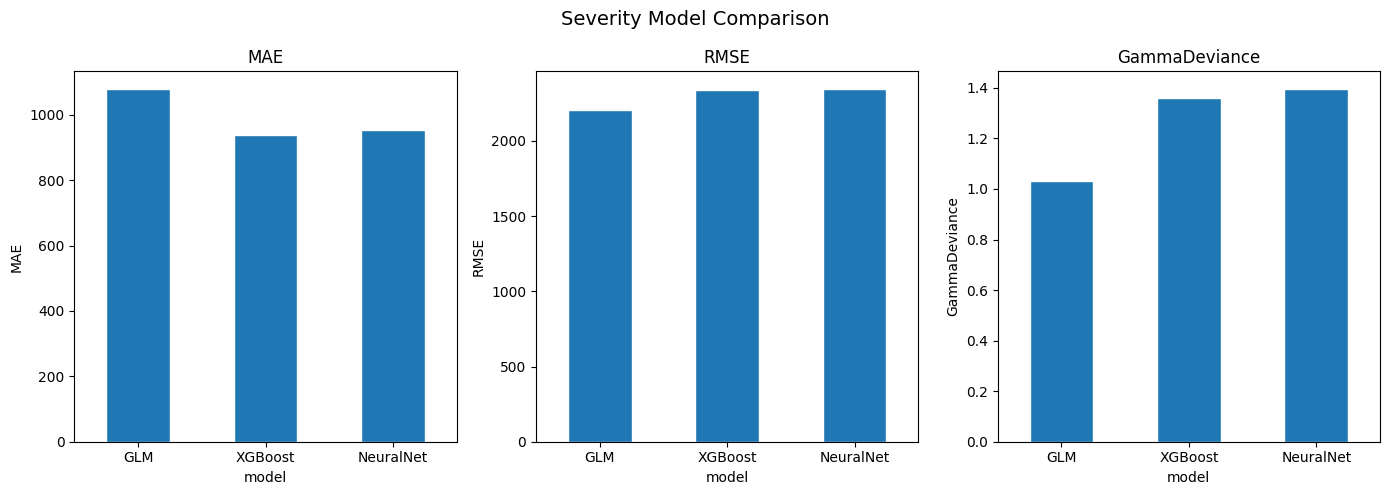

In [14]:
glm_metrics = {'model': 'GLM',       'MAE': 1079,   'RMSE': 2203,   'GammaDeviance': 1.03}
xgb_metrics = {'model': 'XGBoost',   'MAE': 938,    'RMSE': 2340,   'GammaDeviance': 1.36}
nn_metrics  = {'model': 'NeuralNet', 'MAE': 954.45, 'RMSE': 2345.8, 'GammaDeviance': 1.3955}

results = pd.DataFrame([glm_metrics, xgb_metrics, nn_metrics]).set_index('model')
print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'GammaDeviance']):
    results[metric].plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Severity Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../results/17_severity_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()